In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\imdb movies dataset\IMDB TMDB Movie Metadata Big Dataset (1M).csv")
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,Star3,Star4,Writer,Director_of_Photography,Producers,Music_Composer,genres_list,Cast_list,overview_sentiment,all_combined_keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Elliot Page,Ken Watanabe,Christopher Nolan,Wally Pfister,"Thomas Tull, Christopher Nolan, Chris Brigham,...",Hans Zimmer,"['Action', 'Science Fiction', 'Adventure']","['Tim Kelleher', 'Silvie Laguna', 'Natasha Bea...",-0.011111,"['s', 'philosophy', 'skilled', 'kidnapping', '..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Jessica Chastain,Mackenzie Foy,Jonathan Nolan,Hoyte van Hoytema,"Jake Myers, Emma Thomas, Jordan Goldberg, Thom...",Hans Zimmer,"['Adventure', 'Drama', 'Science Fiction']","['Jeff Hephner', 'William Devane', 'Elyes Gabe...",0.045455,"['thoughtful', 'use', 'scientist', 'quantum me..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,Aaron Eckhart,Michael Caine,Jonathan Nolan,Wally Pfister,"Kevin De La Noy, Thomas Tull, Christopher Nola...","Hans Zimmer, James Newton Howard","['Drama', 'Action', 'Crime', 'Thriller']","['Tommy Lister Jr.', 'Edison Chen', 'Beatrice ...",0.025000,"['reign', 'harvey', 'proves', 'partnership', '..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Sigourney Weaver,Michelle Rodriguez,James Cameron,Mauro Fiore,"Jon Landau, Colin Wilson, Laeta Kalogridis, Ja...",James Horner,"['Action', 'Adventure', 'Fantasy', 'Science Fi...","['Carvon Futrell', 'Joel David Moore', 'Jon Cu...",0.041667,"['space war', 'civilization', 'society', 'mari..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,Scarlett Johansson,Jeremy Renner,Sydney Newman,NaN,NaN,NaN,"['Science Fiction', 'Action', 'Adventure']","['Haneyuri', 'Nako Mizusawa', 'Marin', 'Rikako...",0.025000,"['s', 'world', 'begins', 'e', 'global safety',..."


In [3]:
df.shape

(1072255, 42)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072255 entries, 0 to 1072254
Data columns (total 42 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   id                       1072255 non-null  int64  
 1   title                    1072255 non-null  object 
 2   vote_average             1072255 non-null  float64
 3   vote_count               1072255 non-null  int64  
 4   status                   1072255 non-null  object 
 5   release_date             921699 non-null   object 
 6   revenue                  1072255 non-null  int64  
 7   runtime                  1072255 non-null  int64  
 8   adult                    1072255 non-null  bool   
 9   backdrop_path            292826 non-null   object 
 10  budget                   1072255 non-null  int64  
 11  homepage                 115519 non-null   object 
 12  imdb_id                  589364 non-null   object 
 13  original_language        1072255 non-null 

In [6]:
df.isnull().sum()/len(df)*100 

id                          0.000000
title                       0.000000
vote_average                0.000000
vote_count                  0.000000
status                      0.000000
release_date               14.041063
revenue                     0.000000
runtime                     0.000000
adult                       0.000000
backdrop_path              72.690638
budget                      0.000000
homepage                   89.226537
imdb_id                    45.035090
original_language           0.000000
original_title              0.000000
overview                   18.855683
popularity                  0.000000
poster_path                29.642016
tagline                    85.751244
production_companies       53.689001
production_countries       42.562264
spoken_languages           41.058983
keywords                    0.000000
release_year               14.041063
Director                    0.000000
AverageRating              98.904085
Poster_Link                99.741666
C

In [10]:
movies_cleaned_df = df.drop(columns=['homepage','tagline','AverageRating','Poster_Link','Certificate','IMDB_Rating','Meta_score','Star1','Star2','Star3','Star4','Music_Composer','backdrop_path','poster_path','imdb_id','production_companies','production_countries','spoken_languages','Writer','Director_of_Photography','Producers'])
movies_cleaned_df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,original_title,overview,popularity,keywords,release_year,Director,genres_list,Cast_list,overview_sentiment,all_combined_keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,"['rescue', 'mission', 'dream', 'airplane', 'pa...",2010.0,Christopher Nolan,"['Action', 'Science Fiction', 'Adventure']","['Tim Kelleher', 'Silvie Laguna', 'Natasha Bea...",-0.011111,"['s', 'philosophy', 'skilled', 'kidnapping', '..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,...,Interstellar,The adventures of a group of explorers who mak...,140.241,"['rescue', 'future', 'spacecraft', 'race again...",2014.0,Christopher Nolan,"['Adventure', 'Drama', 'Science Fiction']","['Jeff Hephner', 'William Devane', 'Elyes Gabe...",0.045455,"['thoughtful', 'use', 'scientist', 'quantum me..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,"['joker', 'sadism', 'chaos', 'secret identity'...",2008.0,Christopher Nolan,"['Drama', 'Action', 'Crime', 'Thriller']","['Tommy Lister Jr.', 'Edison Chen', 'Beatrice ...",0.025000,"['reign', 'harvey', 'proves', 'partnership', '..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,"['future', 'society', 'culture clash', 'space ...",2009.0,James Cameron,"['Action', 'Adventure', 'Fantasy', 'Science Fi...","['Carvon Futrell', 'Joel David Moore', 'Jon Cu...",0.041667,"['space war', 'civilization', 'society', 'mari..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,"['new york city', 'superhero', 'shield', 'base...",2012.0,Joss Whedon,"['Science Fiction', 'Action', 'Adventure']","['Haneyuri', 'Nako Mizusawa', 'Marin', 'Rikako...",0.025000,"['s', 'world', 'begins', 'e', 'global safety',..."


In [11]:
movies_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072255 entries, 0 to 1072254
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   id                     1072255 non-null  int64  
 1   title                  1072255 non-null  object 
 2   vote_average           1072255 non-null  float64
 3   vote_count             1072255 non-null  int64  
 4   status                 1072255 non-null  object 
 5   release_date           921699 non-null   object 
 6   revenue                1072255 non-null  int64  
 7   runtime                1072255 non-null  int64  
 8   adult                  1072255 non-null  bool   
 9   budget                 1072255 non-null  int64  
 10  original_language      1072255 non-null  object 
 11  original_title         1072255 non-null  object 
 12  overview               870074 non-null   object 
 13  popularity             1072255 non-null  float64
 14  keywords          

In [15]:
movies_cleaned_df['overview'] = df['overview'].fillna('')

In [16]:
movies_cleaned_df['release_year'] = df['release_year'].fillna(-1)

In [17]:
movies_cleaned_df.drop(columns=['release_date'], inplace=True)

In [18]:
movies_cleaned_df.isnull().sum()

id                       0
title                    0
vote_average             0
vote_count               0
status                   0
revenue                  0
runtime                  0
adult                    0
budget                   0
original_language        0
original_title           0
overview                 0
popularity               0
keywords                 0
release_year             0
Director                 0
genres_list              0
Cast_list                0
overview_sentiment       0
all_combined_keywords    0
dtype: int64

In [24]:
movies_cleaned_df.shape

(1072255, 21)

# Using Weighted average for each movie's Average Rating

w = Rv + Cm / v + m
- w:weighted rating
- R: average for the movies as a number 0 to 10(mean) = (Rating)
- v: number of votes for the movie = (votes)
- m: minimum votes required to be listed in the Top 250 
- C: the mean vote across the whole report

In [21]:
#calculate all componenets
v = movies_cleaned_df['vote_count']
R = movies_cleaned_df['vote_average']
C = movies_cleaned_df['vote_average'].mean()
m = movies_cleaned_df['vote_average'].quantile(0.70)

In [22]:
movies_cleaned_df['weighted_average'] = ((R*v) + (C*m)) / (v+m)

In [23]:
movies_cleaned_df.head()

,id,title,vote_average,vote_count,status,revenue,runtime,adult,budget,original_language,...,overview,popularity,keywords,release_year,Director,genres_list,Cast_list,overview_sentiment,all_combined_keywords,weighted_average
0,27205,Inception,8.364,34495,Released,825532764,148,False,160000000,en,...,"Cobb, a skilled thief who commits corporate es...",83.952,"['rescue', 'mission', 'dream', 'airplane', 'pa...",2010.0,Christopher Nolan,"['Action', 'Science Fiction', 'Adventure']","['Tim Kelleher', 'Silvie Laguna', 'Natasha Bea...",-0.011111,"['s', 'philosophy', 'skilled', 'kidnapping', '...",8.363411
1,157336,Interstellar,8.417,32571,Released,701729206,169,False,165000000,en,...,The adventures of a group of explorers who mak...,140.241,"['rescue', 'future', 'spacecraft', 'race again...",2014.0,Christopher Nolan,"['Adventure', 'Drama', 'Science Fiction']","['Jeff Hephner', 'William Devane', 'Elyes Gabe...",0.045455,"['thoughtful', 'use', 'scientist', 'quantum me...",8.416371
2,155,The Dark Knight,8.512,30619,Released,1004558444,152,False,185000000,en,...,Batman raises the stakes in his war on crime. ...,130.643,"['joker', 'sadism', 'chaos', 'secret identity'...",2008.0,Christopher Nolan,"['Drama', 'Action', 'Crime', 'Thriller']","['Tommy Lister Jr.', 'Edison Chen', 'Beatrice ...",0.025000,"['reign', 'harvey', 'proves', 'partnership', '...",8.511321
3,19995,Avatar,7.573,29815,Released,2923706026,162,False,237000000,en,...,"In the 22nd century, a paraplegic Marine is di...",79.932,"['future', 'society', 'culture clash', 'space ...",2009.0,James Cameron,"['Action', 'Adventure', 'Fantasy', 'Science Fi...","['Carvon Futrell', 'Joel David Moore', 'Jon Cu...",0.041667,"['space war', 'civilization', 'society', 'mari...",7.572403
4,24428,The Avengers,7.710,29166,Released,1518815515,143,False,220000000,en,...,When an unexpected enemy emerges and threatens...,98.082,"['new york city', 'superhero', 'shield', 'base...",2012.0,Joss Whedon,"['Science Fiction', 'Action', 'Adventure']","['Haneyuri', 'Nako Mizusawa', 'Marin', 'Rikako...",0.025000,"['s', 'world', 'begins', 'e', 'global safety',...",7.709375


In [27]:
#Sorting data and filter top 20 recommendation
movies_sorted_ranking = movies_cleaned_df.sort_values('weighted_average',ascending=False)
movies_sorted_ranking[['title','vote_count','vote_average','weighted_average','popularity']].head(20)

,title,vote_count,vote_average,weighted_average,popularity
27836,What's New Scooby-Doo? Vol. 3: Halloween Boos ...,50,9.980,9.501402,3.724
29413,"What's New, Scooby-Doo? Vol. 7: Ready to Scare",46,10.000,9.481183,2.678
29332,What's New Scooby-Doo? Vol. 4: Merry Scary Hol...,46,10.000,9.481183,2.092
32281,The 1st 13th Annual Fancy Anvil Awards Show Pr...,40,10.000,9.409094,4.015
28617,"What's New, Scooby-Doo? Vol. 5: Sports Spookta...",48,9.900,9.407673,3.630
28616,"What's New, Scooby-Doo? Vol. 1: Space Ape at t...",48,9.900,9.407673,2.832
28899,"What's New, Scooby-Doo? Vol. 7: Ghosts on the Go!",47,9.872,9.371637,2.675
30773,Scooby-Doo: Mystery in Motion,43,9.900,9.354369,4.145
25723,Scooby-Doo! and the Werewolves,57,9.763,9.351542,5.129
31368,Cartoon Network Christmas: Yuletide Follies,41,9.900,9.329670,2.508


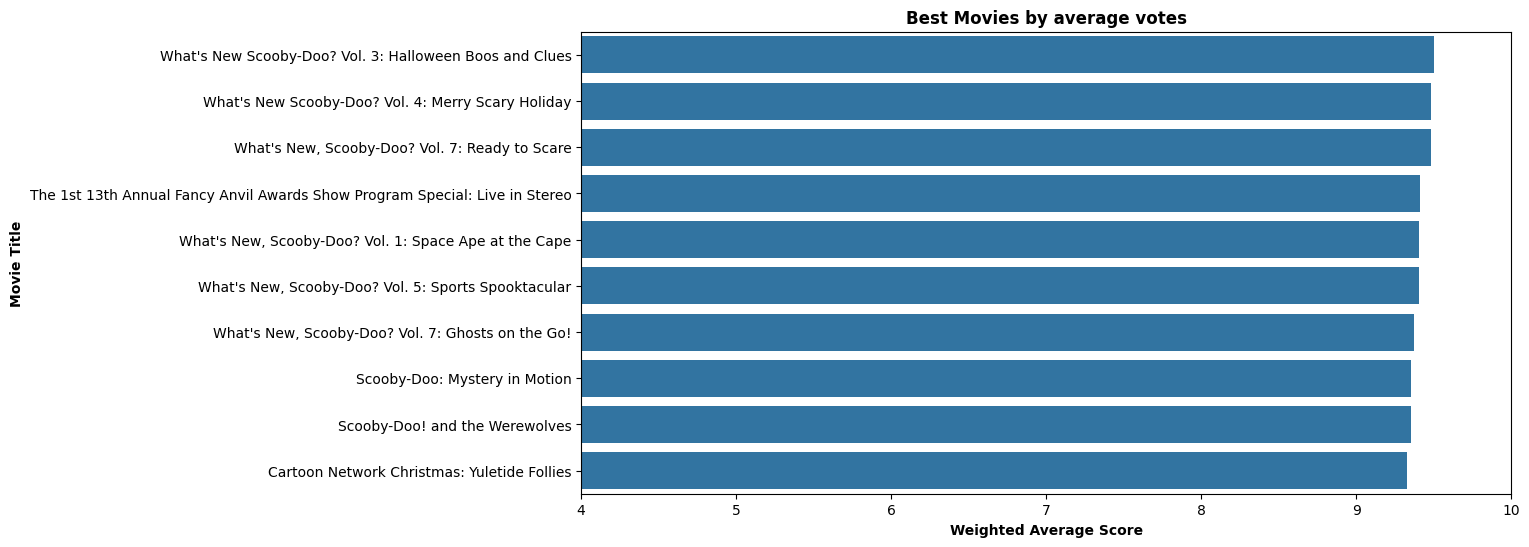

In [28]:
import seaborn as sns
weight_average = movies_sorted_ranking.sort_values('weighted_average',ascending=False)
plt.figure(figsize=(12,6))
axis = sns.barplot(x=weight_average['weighted_average'].head(10), y=weight_average['title'].head(10))
plt.xlim(4,10)
plt.title("Best Movies by average votes", weight='bold')
plt.xlabel("Weighted Average Score",weight='bold')
plt.ylabel("Movie Title",weight='bold')
plt.show()

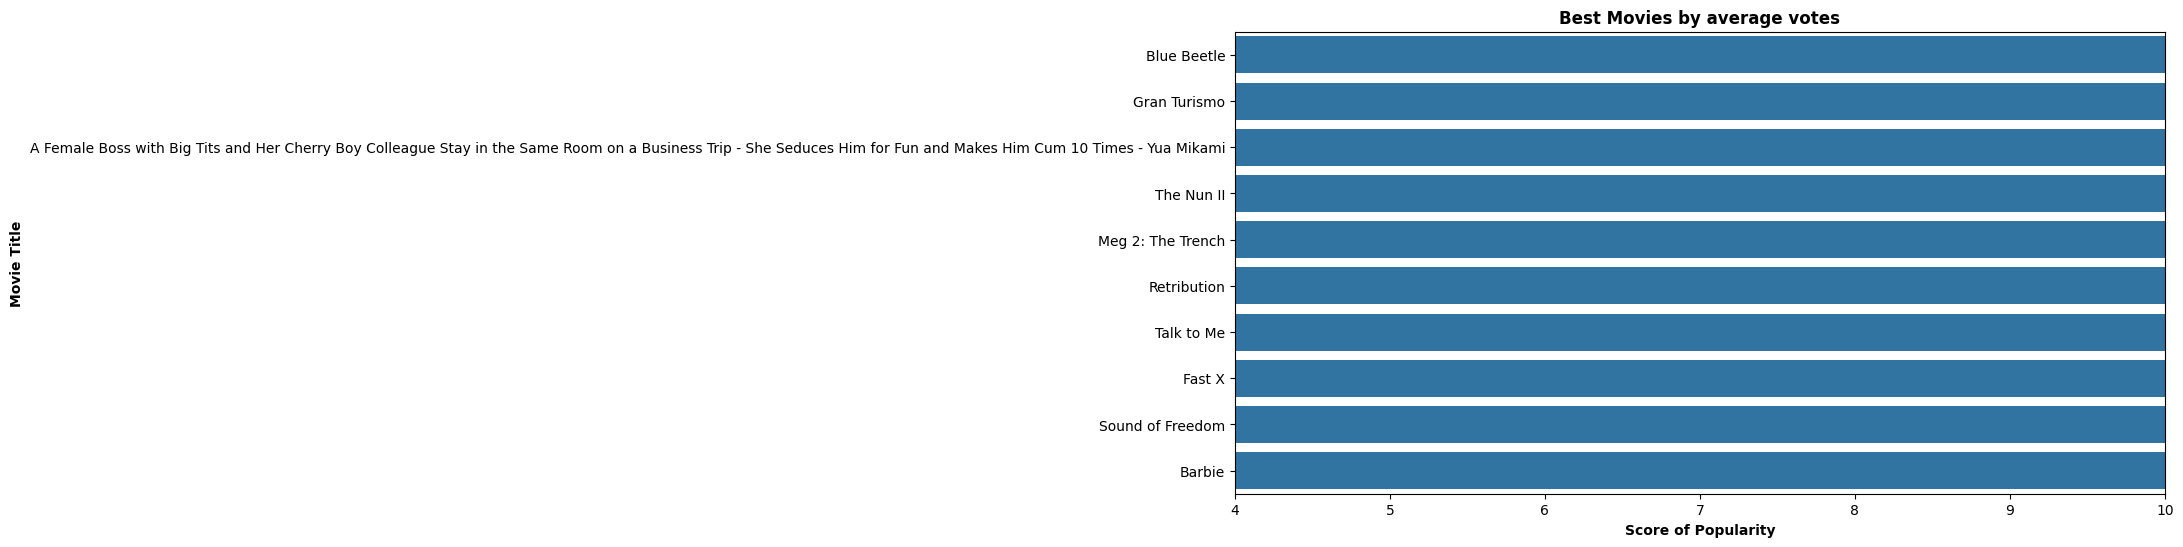

In [30]:
#Filter using popularity
popularity = movies_sorted_ranking.sort_values('popularity',ascending=False)
plt.figure(figsize=(12,6))
axis = sns.barplot(x=popularity['popularity'].head(10), y=popularity['title'].head(10))
plt.xlim(4,10)
plt.title("Best Movies by average votes", weight='bold')
plt.xlabel("Score of Popularity",weight='bold')
plt.ylabel("Movie Title",weight='bold')
plt.show()

In [31]:
popularity.head()

,id,title,vote_average,vote_count,status,revenue,runtime,adult,budget,original_language,...,overview,popularity,keywords,release_year,Director,genres_list,Cast_list,overview_sentiment,all_combined_keywords,weighted_average
3873,565770,Blue Beetle,7.139,1023,Released,124818235,128,False,120000000,en,...,Recent college grad Jaime Reyes returns home f...,2994.357,"['armor', 'superhero', 'family relationships',...",2023.0,Unknown,"['Action', 'Science Fiction', 'Adventure']",['Unknown'],0.028571,"['world', 'armor', 'alien biotechnology', 'jai...",7.123005
5048,980489,Gran Turismo,8.068,702,Released,114800000,135,False,60000000,en,...,The ultimate wish-fulfillment tale of a teenag...,2680.593,"['based on true story', 'racing', 'based on vi...",2023.0,Ron Underwood,"['Action', 'Drama', 'Adventure']","['Madeline Taylor', 'Mark Margolis', 'Spenser ...",0.025000,"['player', 'gran turismo', 'wish', 'series', '...",8.040532
51702,754720,A Female Boss with Big Tits and Her Cherry Boy...,9.000,19,Released,0,120,True,0,ja,...,Yuzuru is this clumsy permavirgin employee who...,2020.286,"['cheating', 'office', 'big tits', 'unfaithful...",2020.0,Dmitriy Dyachenko,['Drama'],"['Stepan Sereda', 'Chris Kaye', 'Yuriy Tsurilo...",0.125000,"['accommodations', 'drinking', 'way', 'clumsy'...",7.993087
7923,968051,The Nun II,6.545,365,Released,231200000,110,False,38500000,en,...,"In 1956 France, a priest is violently murdered...",1692.778,"['france', 'bullying', 'sequel', 'religion', '...",2023.0,William Brookfield,"['Horror', 'Mystery', 'Thriller']","['Simon Chandler', 'Francesca Annis', 'Richard...",-0.500000,"['begins', 'sister irene', 'religion', 'evil',...",6.505551
2130,615656,Meg 2: The Trench,6.912,2034,Released,384056482,116,False,129000000,en,...,An exploratory dive into the deepest depths of...,1567.273,"['based on novel or book', 'sequel', 'shark', ...",2023.0,Tim Burton,"['Action', 'Science Fiction', 'Horror']","['Roland Møller', 'Charlize Theron', 'James Mc...",-0.800000,"['shark', 'civil action', 'mission', 'ocean', ...",6.904297


In [38]:
#Scaling data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
movies_scaled_df = scaler.fit_transform(movies_cleaned_df[['weighted_average','popularity']])
movie_normalized_df = pd.DataFrame(movies_scaled_df, columns=['weighted_average','popularity'])
movie_normalized_df.head()

,weighted_average,popularity
0,0.865843,0.028037
1,0.872087,0.046835
2,0.883280,0.043630
3,0.772592,0.026694
4,0.788740,0.032756


In [39]:
movies_cleaned_df[['normalized_weight_average','normalized_popularoty']] = movie_normalized_df

In [40]:
movies_cleaned_df.head()

,id,title,vote_average,vote_count,status,revenue,runtime,adult,budget,original_language,...,release_year,Director,genres_list,Cast_list,overview_sentiment,all_combined_keywords,weighted_average,normalized_weight_average,normalized_popularoty,score
0,27205,Inception,8.364,34495,Released,825532764,148,False,160000000,en,...,2010.0,Christopher Nolan,"['Action', 'Science Fiction', 'Adventure']","['Tim Kelleher', 'Silvie Laguna', 'Natasha Bea...",-0.011111,"['s', 'philosophy', 'skilled', 'kidnapping', '...",8.363411,0.865843,0.028037,7.645545
1,157336,Interstellar,8.417,32571,Released,701729206,169,False,165000000,en,...,2014.0,Christopher Nolan,"['Adventure', 'Drama', 'Science Fiction']","['Jeff Hephner', 'William Devane', 'Elyes Gabe...",0.045455,"['thoughtful', 'use', 'scientist', 'quantum me...",8.416371,0.872087,0.046835,11.271817
2,155,The Dark Knight,8.512,30619,Released,1004558444,152,False,185000000,en,...,2008.0,Christopher Nolan,"['Drama', 'Action', 'Crime', 'Thriller']","['Tommy Lister Jr.', 'Edison Chen', 'Beatrice ...",0.025000,"['reign', 'harvey', 'proves', 'partnership', '...",8.511321,0.883280,0.043630,10.696255
3,19995,Avatar,7.573,29815,Released,2923706026,162,False,237000000,en,...,2009.0,James Cameron,"['Action', 'Adventure', 'Fantasy', 'Science Fi...","['Carvon Futrell', 'Joel David Moore', 'Jon Cu...",0.041667,"['space war', 'civilization', 'society', 'mari...",7.572403,0.772592,0.026694,7.062807
4,24428,The Avengers,7.710,29166,Released,1518815515,143,False,220000000,en,...,2012.0,Joss Whedon,"['Science Fiction', 'Action', 'Adventure']","['Haneyuri', 'Nako Mizusawa', 'Marin', 'Rikako...",0.025000,"['s', 'world', 'begins', 'e', 'global safety',...",7.709375,0.788740,0.032756,8.281383


In [41]:
movies_cleaned_df['score'] = movies_cleaned_df['normalized_weight_average']*0.5 + movies_cleaned_df['normalized_popularoty']*0.5
movie_scored_df = movies_cleaned_df.sort_values(['score'],ascending=False)
movie_scored_df[['title','normalized_weight_average','normalized_popularoty','score']].head(20)

,title,normalized_weight_average,normalized_popularoty,score
5048,Gran Turismo,0.827780,0.895215,0.861497
3873,Blue Beetle,0.719613,1.000000,0.859807
51702,A Female Boss with Big Tits and Her Cherry Boy...,0.822186,0.674698,0.748442
2130,Meg 2: The Trench,0.693830,0.523409,0.608619
4014,Talk to Me,0.728330,0.487088,0.607709
7923,The Nun II,0.646822,0.565323,0.606073
9951,Retribution,0.676476,0.516712,0.596594
6396,Sound of Freedom,0.815378,0.371043,0.593210
1799,Elemental,0.793477,0.336948,0.565212
1110,Fast X,0.735843,0.392494,0.564168
